# GitHub Open-Source AI Repository Growth
    This project transforms GitHub repository data into actionable insights about AI technology trends, community interest, repository activity, and open-source practices.
#### Objective
    The project aims to use GitHub data to understand how AI repositories are growing, which technologies are popular, what types of repositories receive more community attention, and how active and open-source they are.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("github_top_repositories.csv")
df.head()

,Domain,Repository Name,Full Name,Description,Primary Language,Stars Count,Forks Count,Open Issues Count,Has Wiki,Has Pages,Has Projects,Size (KB),Created At,Updated At,Pushed At,Default Branch,Owner Login,Owner Type,License,Topics
0,Machine Learning,tensorflow,tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,C++,194622,75263,4302,False,False,True,1302841,2015-11-07T01:19:20Z,2026-04-10T10:08:00Z,2026-04-10T10:13:20Z,master,tensorflow,Organization,Apache License 2.0,"deep-learning, deep-neural-networks, distribut..."
1,Machine Learning,transformers,huggingface/transformers,🤗 Transformers: the model-definition framework...,Python,159148,32816,2365,True,False,True,463713,2018-10-29T13:56:00Z,2026-04-10T10:08:23Z,2026-04-10T10:08:12Z,main,huggingface,Organization,Apache License 2.0,"audio, deep-learning, deepseek, gemma, glm, ha..."
2,Machine Learning,prompts.chat,f/prompts.chat,"f.k.a. Awesome ChatGPT Prompts. Share, discove...",HTML,159022,20824,41,True,True,True,297750,2022-12-05T13:54:13Z,2026-04-10T10:14:17Z,2026-04-10T04:05:14Z,main,f,User,Other,"ai, artificial-intelligence, awesome-list, cha..."
3,Machine Learning,pytorch,pytorch/pytorch,Tensors and Dynamic neural networks in Python ...,Python,98996,27457,18279,True,False,True,1291190,2016-08-13T05:26:41Z,2026-04-10T09:57:12Z,2026-04-10T10:12:27Z,main,pytorch,Organization,Other,"autograd, deep-learning, gpu, machine-learning..."
4,Machine Learning,LLMs-from-scratch,rasbt/LLMs-from-scratch,Implement a ChatGPT-like LLM in PyTorch from s...,Jupyter Notebook,90420,13854,4,False,False,False,15750,2023-07-23T18:15:57Z,2026-04-10T09:43:16Z,2026-04-06T02:05:07Z,main,rasbt,User,Other,"ai, artificial-intelligence, chatbot, chatgpt,..."


In [3]:
df.shape

(5000, 20)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Domain             5000 non-null   str  
 1   Repository Name    5000 non-null   str  
 2   Full Name          5000 non-null   str  
 3   Description        5000 non-null   str  
 4   Primary Language   5000 non-null   str  
 5   Stars Count        5000 non-null   int64
 6   Forks Count        5000 non-null   int64
 7   Open Issues Count  5000 non-null   int64
 8   Has Wiki           5000 non-null   bool 
 9   Has Pages          5000 non-null   bool 
 10  Has Projects       5000 non-null   bool 
 11  Size (KB)          5000 non-null   int64
 12  Created At         5000 non-null   str  
 13  Updated At         5000 non-null   str  
 14  Pushed At          5000 non-null   str  
 15  Default Branch     5000 non-null   str  
 16  Owner Login        5000 non-null   str  
 17  Owner Type         5000 n

In [5]:
df.isnull().sum()

Domain               0
Repository Name      0
Full Name            0
Description          0
Primary Language     0
Stars Count          0
Forks Count          0
Open Issues Count    0
Has Wiki             0
Has Pages            0
Has Projects         0
Size (KB)            0
Created At           0
Updated At           0
Pushed At            0
Default Branch       0
Owner Login          0
Owner Type           0
License              0
Topics               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(3)

In [7]:
df=df.drop_duplicates()
df.duplicated().sum()
df.shape

(4997, 20)

In [8]:
date_columns=['Created At', 'Updated At', 'Pushed At']
for col in date_columns:
    df[col]=pd.to_datetime(df[col])

In [9]:
df[['Created At', 'Updated At', 'Pushed At']].dtypes

Created At    datetime64[us, UTC]
Updated At    datetime64[us, UTC]
Pushed At     datetime64[us, UTC]
dtype: object

In [10]:
df['Domain'].value_counts()

Domain
Machine Learning               200
Deep Learning                  200
Python                         200
Java                           200
C++                            200
Go                             200
Rust                           200
Data Science                   200
Web Development                200
Android                        200
iOS                            200
Blockchain                     200
Cybersecurity                  200
DevOps                         200
Frontend Development           200
Backend Development            200
Game Development               200
Cloud Computing                200
Artificial Intelligence        200
Natural Language Processing    200
Computer Vision                200
Internet of Things             200
Robotics                       200
Software Engineering           200
JavaScript                     197
Name: count, dtype: int64

In [11]:
df['Primary Language'].value_counts()

Primary Language
Python         1086
0               602
C++             486
JavaScript      459
Go              436
               ... 
Prolog            1
Scheme            1
Tcl               1
VHDL              1
Common Lisp       1
Name: count, Length: 77, dtype: int64

In [12]:
df[df['Primary Language'] == '0'][['Repository Name', 'Primary Language']].head()

,Repository Name,Primary Language
6,cs-video-courses,0
8,llm-course,0
11,awesome-scalability,0
21,100-Days-Of-ML-Code,0
46,500-AI-Machine-learning-Deep-learning-Computer...,0


In [13]:
df['Primary Language'] = df['Primary Language'].replace('0', 'Unknown')

df['Primary Language'].value_counts().head(10)

Primary Language
Python              1086
Unknown              602
C++                  486
JavaScript           459
Go                   436
Java                 370
Rust                 323
TypeScript           278
Jupyter Notebook     224
HTML                 107
Name: count, dtype: int64

In [16]:
df['Owner Type'].value_counts()

Owner Type
Organization    2936
User            2061
Name: count, dtype: int64

In [17]:
df['License'].value_counts()

License
MIT License                                                   1643
Apache License 2.0                                            1187
Other                                                          679
0                                                              641
GNU General Public License v3.0                                287
GNU Affero General Public License v3.0                         126
BSD 3-Clause "New" or "Revised" License                        107
Creative Commons Zero v1.0 Universal                            87
Creative Commons Attribution Share Alike 4.0 International      35
GNU General Public License v2.0                                 33
Mozilla Public License 2.0                                      31
BSD 2-Clause "Simplified" License                               31
GNU Lesser General Public License v3.0                          27
GNU Lesser General Public License v2.1                          19
Creative Commons Attribution 4.0 International        

In [18]:
df['License'] = df['License'].replace('0', 'no license')
df['License'].value_counts().head()

License
MIT License                        1643
Apache License 2.0                 1187
Other                               679
no license                          641
GNU General Public License v3.0     287
Name: count, dtype: int64

In [19]:
df['Default Branch'].value_counts().head(20)

Default Branch
master         2566
main           1991
develop         155
dev              79
gh-pages         13
development      13
devel            11
trunk             9
staging           7
next              7
4.x               5
v2                5
release           5
ue5-dev           4
canary            4
dev-v2            4
v4                4
live              3
default           3
2.x               3
Name: count, dtype: int64

In [20]:
df['Topics'].head(10)

0    deep-learning, deep-neural-networks, distribut...
1    audio, deep-learning, deepseek, gemma, glm, ha...
2    ai, artificial-intelligence, awesome-list, cha...
3    autograd, deep-learning, gpu, machine-learning...
4    ai, artificial-intelligence, chatbot, chatgpt,...
5    data-science, education, machine-learning, mac...
6    algorithms, bioinformatics, computational-biol...
7    ai, alerting, cncf, data-visualization, databa...
8    course, large-language-models, llm, machine-le...
9    book, chinese, computer-vision, deep-learning,...
Name: Topics, dtype: str

In [21]:
df[['Stars Count', 'Forks Count', 'Open Issues Count', 'Size (KB)']].describe()

,Stars Count,Forks Count,Open Issues Count,Size (KB)
count,4997.000000,4997.000000,4997.000000,4.997000e+03
mean,16469.393636,2688.998199,298.454473,2.583853e+05
std,25266.033931,5598.186404,904.929494,1.569189e+06
min,35.000000,0.000000,0.000000,0.000000e+00
25%,2266.000000,294.000000,10.000000,4.968000e+03
50%,8347.000000,993.000000,59.000000,3.076700e+04
75%,21920.000000,2831.000000,251.000000,1.415390e+05
max,420610.000000,106780.000000,18279.000000,6.256578e+07


In [22]:
df[['Created At', 'Updated At', 'Pushed At']].agg(['min', 'max'])


,Created At,Updated At,Pushed At
min,2009-01-05 14:00:43+00:00,2024-03-14 22:40:50+00:00,2016-03-09 11:44:35+00:00
max,2026-04-05 01:12:07+00:00,2026-04-10 10:36:50+00:00,2026-04-10 10:35:34+00:00


In [23]:
print("Updated before Created:",
      (df['Updated At'] < df['Created At']).sum())

print("Pushed before Created:",
      (df['Pushed At'] < df['Created At']).sum())

Updated before Created: 0
Pushed before Created: 0


## Insight 1 — AI Repository Growth Over Time
Which years had the highest number of AI repositories created?

In [24]:
df['Created Year']=df['Created At'].dt.year
yearly_repos=df['Created Year'].value_counts()
yearly_repos

Created Year
2018    527
2017    513
2019    481
2016    449
2020    432
2021    390
2022    367
2023    356
2015    338
2014    260
2013    197
2024    192
2025    161
2012    121
2011     87
2010     68
2026     34
2009     24
Name: count, dtype: int64

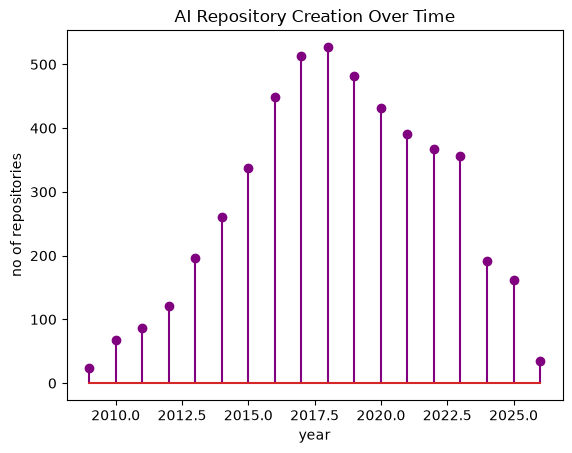

In [65]:
plt.stem(yearly_repos.index, yearly_repos.values,linefmt='purple')
plt.title('AI Repository Creation Over Time')
plt.xlabel('year')
plt.ylabel('no of repositories')
plt.show()

## Insight 2 — AI Domain Popularity by Stars
Which AI domain has the highest average repository popularity based on GitHub stars?

In [26]:
domain_stars = df.groupby('Domain')['Stars Count'].mean().sort_values(ascending=False)

domain_stars.head(10)

Domain
Python              62587.390000
JavaScript          40832.664975
Go                  33460.600000
Machine Learning    27643.605000
Rust                27446.770000
C++                 26762.245000
Java                25368.880000
Deep Learning       24997.840000
Android             23458.885000
iOS                 16707.230000
Name: Stars Count, dtype: float64

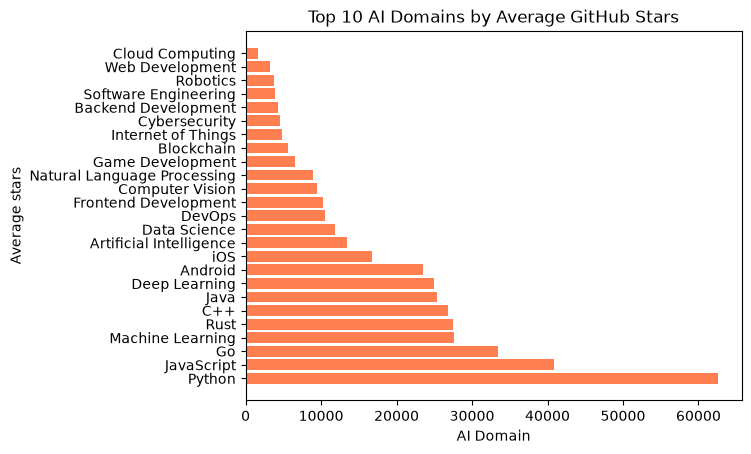

In [67]:
plt.barh(domain_stars.index,domain_stars.values, color='coral')
plt.title('Top 10 AI Domains by Average GitHub Stars')
plt.xlabel('AI Domain')
plt.ylabel('Average stars')
plt.show()

## Insight 3 — Most Popular Programming Languages
Which programming languages are most commonly used in the repositories in our dataset?

In [28]:
lang_counts=(df[df['Primary Language'] != 'unknown']['Primary Language'].value_counts())
lang_counts.head(10)

Primary Language
Python              1086
Unknown              602
C++                  486
JavaScript           459
Go                   436
Java                 370
Rust                 323
TypeScript           278
Jupyter Notebook     224
HTML                 107
Name: count, dtype: int64

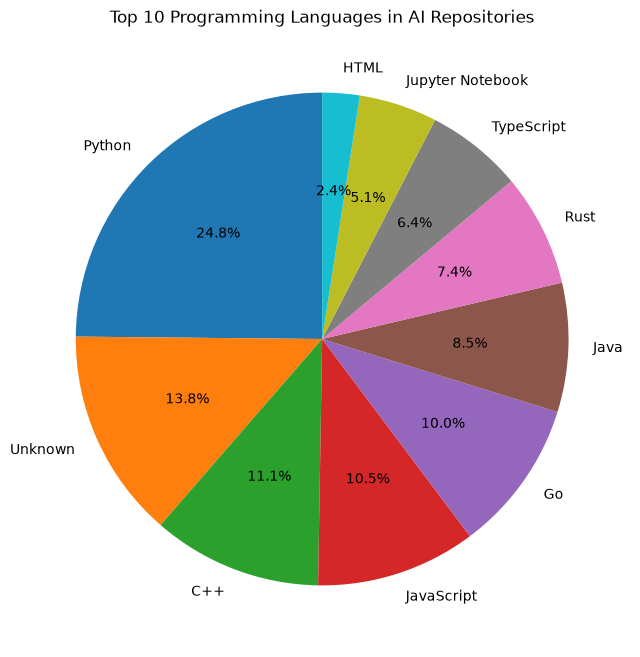

In [29]:
plt.figure(figsize=(8, 8))
plt.pie(
    lang_counts.head(10).values,
    labels=lang_counts.head(10).index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Top 10 Programming Languages in AI Repositories')
plt.show()

## Insight 4 — Organization vs Individual Repositories
How do repositories owned by Organizations differ from repositories owned by individual Users in terms of popularity and community engagement?

In [33]:
owner_analysis = df.groupby('Owner Type')[['Stars Count', 'Forks Count', 'Open Issues Count']].mean()
owner_analysis

,Stars Count,Forks Count,Open Issues Count
Owner Type,,,
Organization,18318.385899,3058.060627,450.161444
User,13835.409510,2163.249879,82.340126


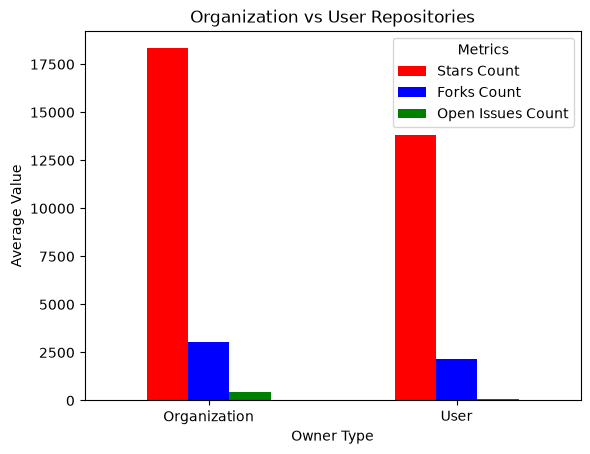

In [83]:
owner_analysis.plot(kind='bar',figsize=(10, 6),color=['red', 'blue', 'green'])

plt.title('Organization vs User Repositories')
plt.xlabel('Owner Type')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(title='Metrics')


plt.show()

## Insight 5 — Repository Age vs Popularity
Does repository age have a relationship with GitHub stars?

In [50]:
year_star_avg = df.groupby('Created Year')['Stars Count'].mean()

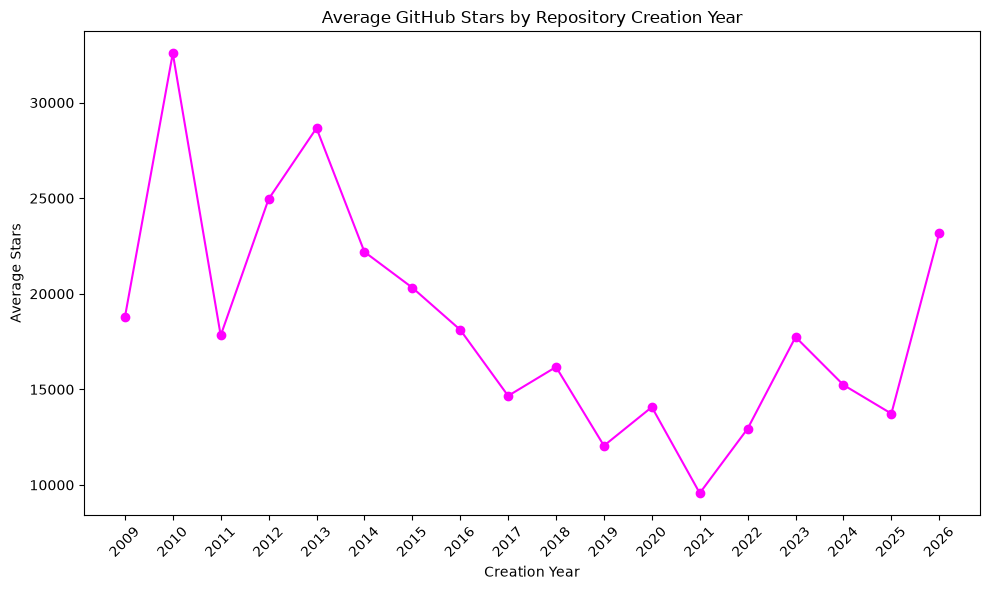

In [71]:
plt.figure(figsize=(10, 6))

plt.plot(
    year_star_avg.index,
    year_star_avg.values,
    marker='o',
     color='magenta'
)

plt.title('Average GitHub Stars by Repository Creation Year')
plt.xlabel('Creation Year')
plt.ylabel('Average Stars')

plt.xticks(year_star_avg.index, rotation=45)
plt.tight_layout()
plt.show()

## Insight 6 — Active vs Inactive Repositories
Are recently updated repositories more popular than less recently updated repositories?

In [52]:
latest_date = df['Updated At'].max()
latest_date

Timestamp('2026-04-10 10:36:50+0000', tz='UTC')

In [54]:
df['Days Since Update'] = (latest_date - df['Updated At']).dt.days

In [56]:
df['Activity Status'] = df['Days Since Update'].apply(lambda x: 'Active' if x <= 365 else 'Inactive')

In [57]:
activity_analysis = df.groupby('Activity Status')['Stars Count'].mean()

activity_analysis

Activity Status
Active      16508.885657
Inactive       63.750000
Name: Stars Count, dtype: float64

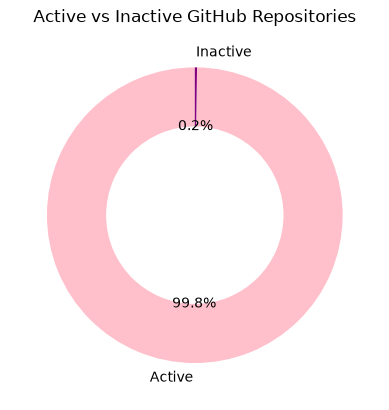

In [75]:
activity_counts = df['Activity Status'].value_counts()

plt.pie( activity_counts.values,
    labels=activity_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4},
    colors=['pink','purple']
)

plt.title('Active vs Inactive GitHub Repositories')
plt.show()

## Insight 7 — Open-Source License Trends
Which open-source licenses are most commonly used by AI repositories?

In [60]:
license_counts = df['License'].value_counts()

license_counts.head(10)

License
MIT License                                                   1643
Apache License 2.0                                            1187
Other                                                          679
no license                                                     641
GNU General Public License v3.0                                287
GNU Affero General Public License v3.0                         126
BSD 3-Clause "New" or "Revised" License                        107
Creative Commons Zero v1.0 Universal                            87
Creative Commons Attribution Share Alike 4.0 International      35
GNU General Public License v2.0                                 33
Name: count, dtype: int64

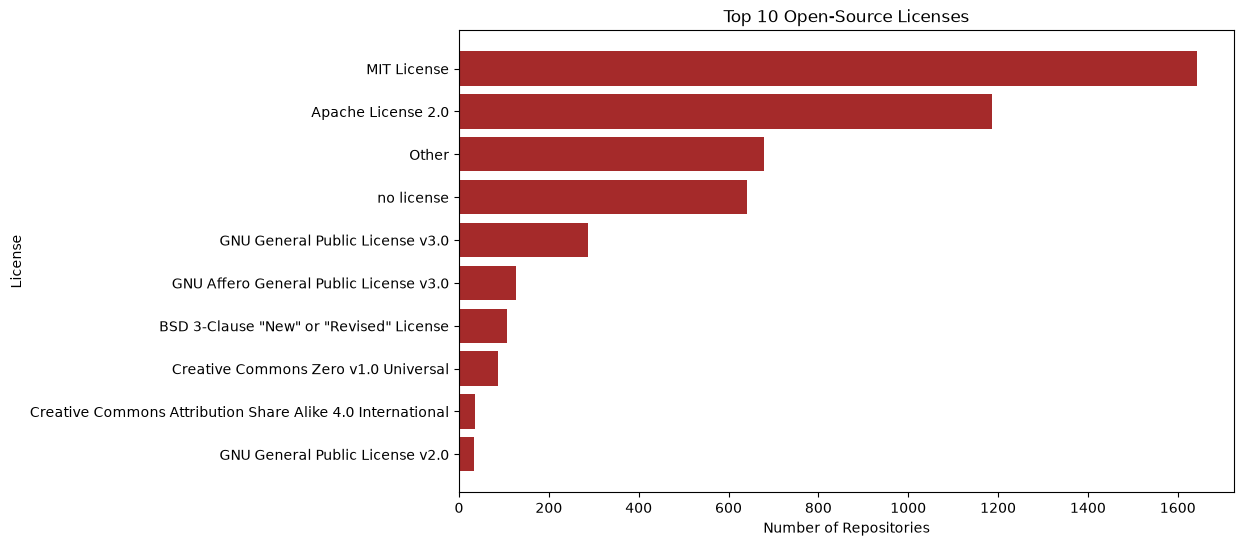

In [77]:
top_10_licenses = license_counts.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_licenses.index,
    top_10_licenses.values,
    color=['brown']
)

plt.title('Top 10 Open-Source Licenses')
plt.xlabel('Number of Repositories')
plt.ylabel('License')
plt.show()

## Insight 8 — Repository Size vs Popularity
Do larger GitHub repositories tend to have more stars?

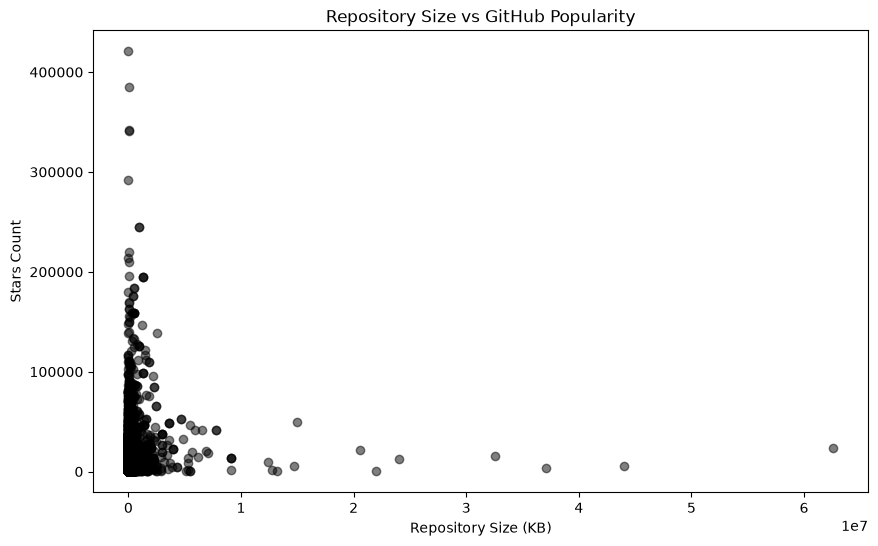

In [80]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Size (KB)'],
    df['Stars Count'],
    alpha=0.5,
    color='black'
)

plt.title('Repository Size vs GitHub Popularity')
plt.xlabel('Repository Size (KB)')
plt.ylabel('Stars Count')


plt.show()

# Conclusion 

This project helps us understand the growth, popularity, technology choices, activity, and characteristics of open-source AI repositories on GitHub.

From the analysis, we can identify which AI domains and programming languages have stronger community interest, understand how repository popularity differs by ownership type, and compare active and inactive repositories. We can also understand the most commonly used open-source licenses and examine how repository characteristics such as age and size relate to popularity.

These insights can be useful for technology companies, developers, researchers, and open-source teams when exploring the AI ecosystem. Companies can use this type of analysis to understand technology trends and community interest, while developers can identify commonly used technologies and understand what types of repositories receive more attention.

Overall, the project shows how GitHub data can be converted into meaningful insights that support technology research, open-source strategy, and data-driven decision-making.